## Упражнение 06. Матрица диаграмм рассеяния (scatter matrix)

In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

### 1. Создаем соединение с базой данных с помощью библиотеки sqlite3

In [2]:
conn=sqlite3.connect('../data/checking-logs.sqlite')

### 2. Делаем всё необходимое, чтобы получить график как на примере:
#### - Построй DataFrame, где для каждого пользователя из группы test есть: средняя дельта, число визитов в «Ленту», число коммитов;
#### - Не учитывай project1 при расчётах средней дельты и числа коммитов;
#### - Число коммитов возьми из таблицы checker;
#### - Размер фигуры — тот же; размер шрифта и палитру выбирай сам;
#### - Размер точек — 200;
#### - Толщина линий диагональных графиков (KDE) — 3.


In [8]:
q_chker = """SELECT * FROM checker;"""
q_pageviews= """SELECT * FROM pageviews;"""
q_deadlines= """SELECT * FROM deadlines;"""
df_chker = pd.io.sql.read_sql(q_chker, conn, parse_dates=["timestamp", ],)
df_pageviews = pd.io.sql.read_sql(q_pageviews, conn, parse_dates=["datetime", ],)
df_deadlines = pd.io.sql.read_sql(q_deadlines, conn, parse_dates=["deadlines", ],)
df_chker.head()

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,NaN,admin_1
1,1,ready,0,2020-04-16 21:12:54.708365,5,code_rvw,admin_1
2,2,checking,0,2020-04-16 21:46:47.769088,7,NaN,admin_1
3,3,ready,0,2020-04-16 21:46:48.121217,7,lab02,admin_1
4,4,checking,0,2020-04-16 21:53:01.862637,6,code_rvw,admin_1


In [9]:
df_pageviews.head()

,index,uid,datetime
0,0,admin_1,2020-04-17 12:01:08.463179
1,1,admin_1,2020-04-17 12:01:23.743946
2,2,admin_3,2020-04-17 12:17:39.287778
3,3,admin_3,2020-04-17 12:17:40.001768
4,4,admin_1,2020-04-17 12:27:30.646665


In [10]:
df_deadlines.head()

,index,labs,deadlines
0,0,laba04,2020-04-26 23:59:59
1,1,laba04s,2020-04-26 23:59:59
2,2,laba05,2020-05-03 23:59:59
3,4,laba06,2020-05-24 23:59:59
4,5,laba06s,2020-05-24 23:59:59


In [13]:
df= (df_chker[(df_chker["status"] == "ready") & (df_chker["numTrials"] == 1) & (df_chker["labname"].isin([
"laba04", "laba04s", "laba05", "laba06", "laba06s", "project1",], )) & 
(df_chker["uid"].str.startswith("user_", ))].groupby(["uid", "labname", ], )["timestamp"].min().reset_index(name="first_commit", )
.merge(df_pageviews.groupby("uid", )["datetime"].min().reset_index(name="first_view", ), on="uid", how="left",)
.query("first_view.notna()", ) .merge( df_deadlines, left_on="labname", right_on="labs",).query('labname != "project1"', )
.assign(diff_hours=lambda x: (x["deadlines"].astype("int64", ) // 10**9 - x["first_commit"].astype("int64", ) // 10**9) / 3600)
    .groupby("uid", )
    .agg(avg_diff=("diff_hours", "mean", ), )
    .reset_index()
    .merge(df_pageviews[df_pageviews["uid"].str.startswith("user_", )].groupby("uid", ).size().rename("pageviews", ),
on="uid", how="left",)
    .merge(df_chker[(df_chker["uid"].str.startswith("user_", )) & (df_chker["labname"] != "project1")].groupby("uid", ).size().rename("commits", ),
on="uid",how="left",))
df

,uid,avg_diff,pageviews,commits
0,user_1,-441.332833,28,63
1,user_10,-441.322778,89,21
2,user_14,-440.992037,143,62
3,user_17,-441.335722,47,52
4,user_18,-441.145185,3,5
5,user_19,-441.374097,16,119
6,user_21,-441.209514,10,66
7,user_25,-441.304556,179,80
8,user_28,-441.311222,149,61
9,user_3,-441.292222,317,19


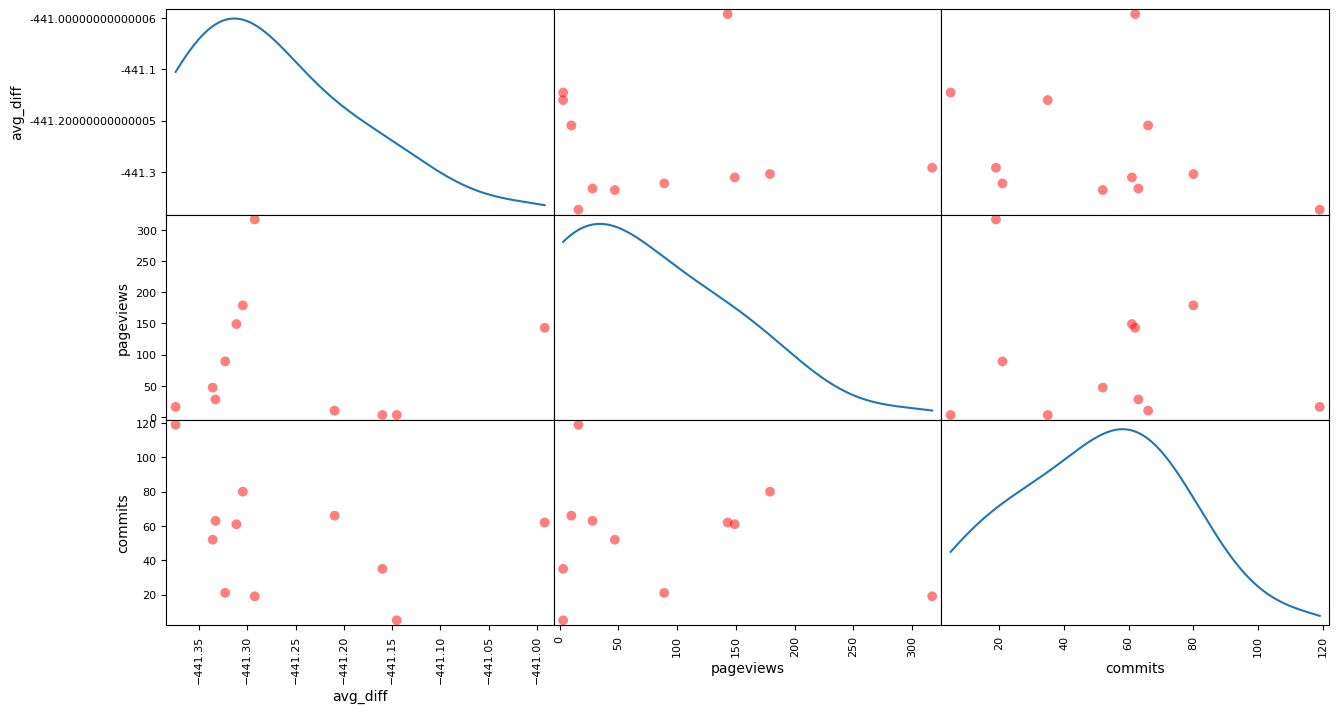

In [16]:
scatter_matrix(
    df[[
        "avg_diff",
        "pageviews",
        "commits",
    ]],
    s=200,
    color="red",
    diagonal="kde",
    figsize=(15, 8, ),
    hist_kwds={"linewidth": 3, },
);

### Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, мало коммитов?

Нет

### Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, малая средняя разница между первым коммитом и дедлайном лабораторной?

Нет

### Можно ли сказать, что много пользователей с малым числом коммитов и немного — с большим числом коммитов?

Да

### Можно ли сказать, что много пользователей с малой средней разницей и немного — с большой средней разницей?

Нет

### Закрываем соединение с базой данных.

In [18]:
conn.close()